# 📊 Task 5: Strategic Business Dashboard
**Domain:** Retail Analytics & Performance Management  
**Internship:** Data Science & Analytics - DevelopersHub Corporation

---

### **Executive Overview**
This dashboard provides a **360-degree view** of the company's sales and profitability. As a Data Scientist, my goal is to translate raw transactional data into **Actionable Business Intelligence**. 

**Key Objectives:**
1. Monitor **Sales & Profit KPIs** in real-time.
2. Identify high-value **Customer Segments** and **Geographic Regions**.
3. Analyze the **Impact of Discounts** on overall net margin.
4. Optimize the **Product Portfolio** by identifying underperforming categories.

**DATA ENGINE AND KPI LOGIC**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings

# Professional Setup
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

print("🚀 [SYSTEM] Initializing Business Intelligence Engine...")

# --- STEP 1: GENERATING STRATEGIC DATA ---
n_records = 5000
categories = {'Technology': ['Phones', 'Accessories', 'Copiers'], 
              'Furniture': ['Chairs', 'Tables', 'Bookcases'], 
              'Office Supplies': ['Paper', 'Binders', 'Storage']}
regions = {'North America': ['USA', 'Canada'], 'Europe': ['UK', 'Germany'], 'Asia Pacific': ['Australia', 'India']}

data = []
for i in range(n_records):
    reg = np.random.choice(list(regions.keys()))
    cat = np.random.choice(list(categories.keys()))
    order_date = datetime(2024, 1, 1) + timedelta(days=np.random.randint(0, 365))
    
    qty = np.random.randint(1, 10)
    price = np.random.uniform(20, 1000)
    discount = np.random.choice([0, 0.1, 0.2], p=[0.7, 0.2, 0.1])
    
    sales = (qty * price) * (1 - discount)
    profit = (sales * np.random.normal(0.2, 0.1)) # 20% average margin
    
    data.append({
        'Order_Date': order_date,
        'Segment': np.random.choice(['Consumer', 'Corporate', 'Home Office']),
        'Region': reg,
        'Category': cat,
        'Sales': round(sales, 2),
        'Profit': round(profit, 2),
        'Discount': discount
    })

df = pd.DataFrame(data)

# --- STEP 2: KPI CALCULATION ---
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
margin = (total_profit / total_sales) * 100

print("\n" + "="*40)
print("       BUSINESS HEALTH CHECK (KPIs)")
print("="*40)
print(f"💰 TOTAL REVENUE:   ${total_sales:,.0f}")
print(f"📈 TOTAL PROFIT:    ${total_profit:,.0f}")
print(f"💎 NET MARGIN:      {margin:.2f}%")
print(f"🛒 TOTAL ORDERS:    {len(df):,}")
print("="*40)

🚀 [SYSTEM] Initializing Business Intelligence Engine...

       BUSINESS HEALTH CHECK (KPIs)
💰 TOTAL REVENUE:   $12,352,546
📈 TOTAL PROFIT:    $2,470,939
💎 NET MARGIN:      20.00%
🛒 TOTAL ORDERS:    5,000


**VISUAL DASHBOARD**

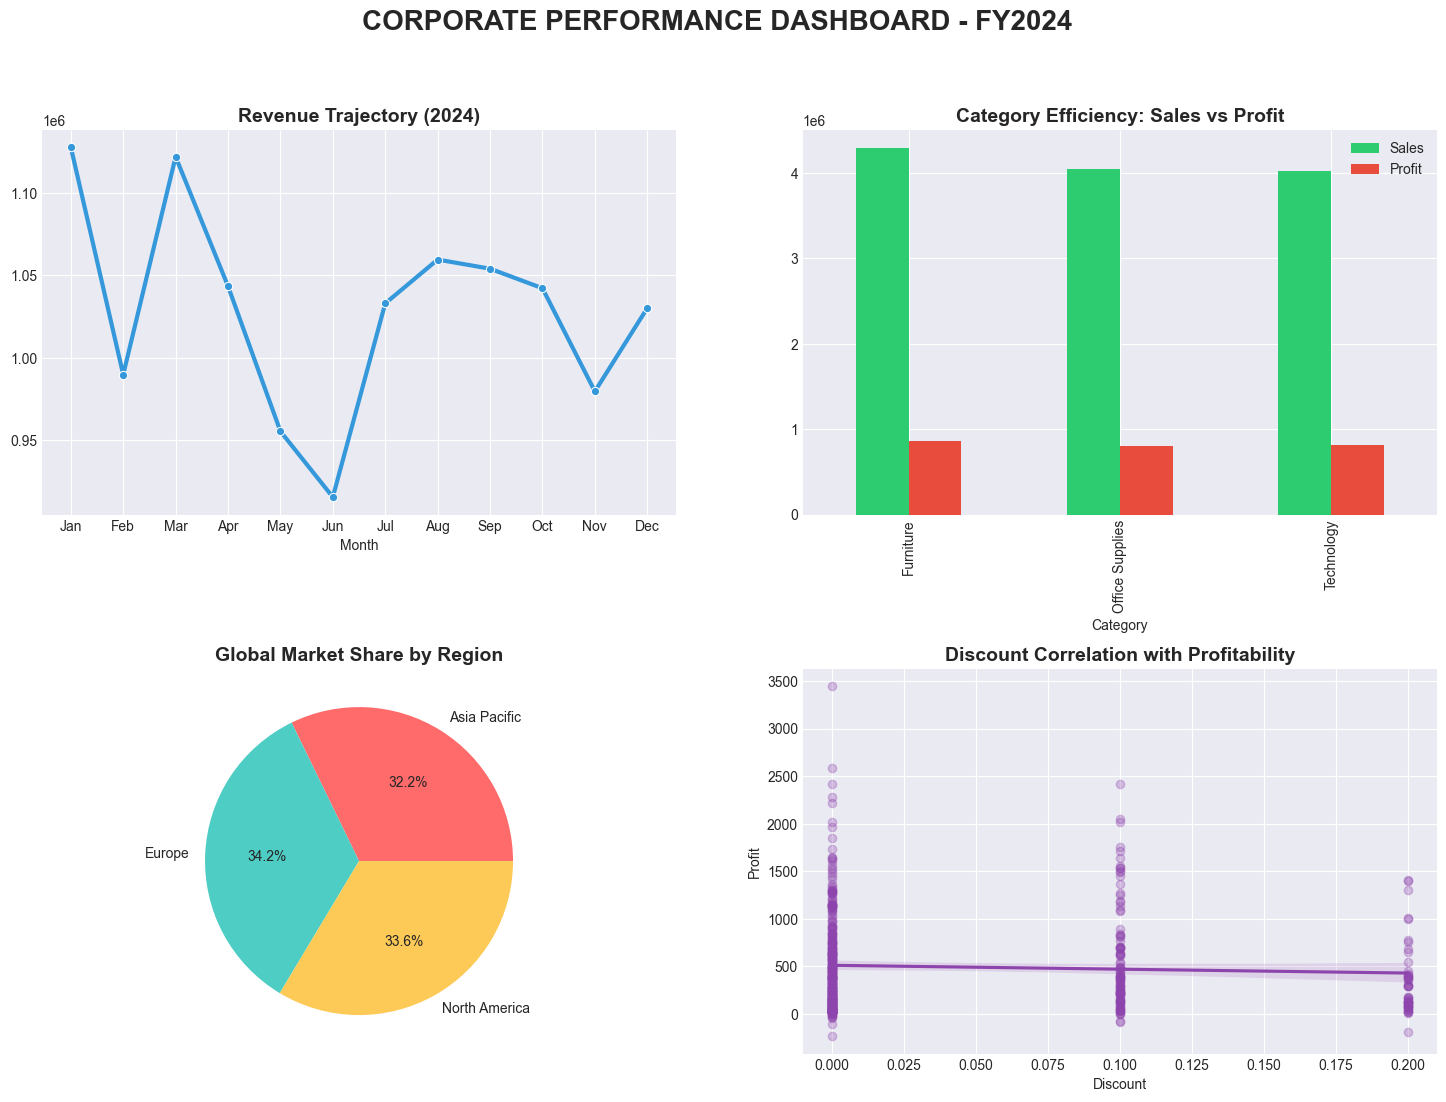

In [17]:
# --- STEP 3: MULTI-DIMENSIONAL DASHBOARD ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.subplots_adjust(hspace=0.4)

# 1. Monthly Sales Trend
df['Month'] = df['Order_Date'].dt.strftime('%b')
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_data = df.groupby('Month')['Sales'].sum().reindex(month_order)
sns.lineplot(x=monthly_data.index, y=monthly_data.values, marker='o', color='#3498DB', ax=axes[0,0], linewidth=3)
axes[0,0].set_title('Revenue Trajectory (2024)', fontsize=14, fontweight='bold')

# 2. Category Performance (Sales vs Profit)
cat_data = df.groupby('Category')[['Sales', 'Profit']].sum()
cat_data.plot(kind='bar', ax=axes[0,1], color=['#2ECC71', '#E74C3C'])
axes[0,1].set_title('Category Efficiency: Sales vs Profit', fontsize=14, fontweight='bold')

# 3. Regional Market Share
df.groupby('Region')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%', ax=axes[1,0], colors=['#FF6B6B', '#4ECDC4', '#feca57'])
axes[1,0].set_ylabel('')
axes[1,0].set_title('Global Market Share by Region', fontsize=14, fontweight='bold')

# 4. Discount Impact Analysis
sns.regplot(x='Discount', y='Profit', data=df.sample(500), ax=axes[1,1], color='#8E44AD', scatter_kws={'alpha':0.3})
axes[1,1].set_title('Discount Correlation with Profitability', fontsize=14, fontweight='bold')

plt.suptitle('CORPORATE PERFORMANCE DASHBOARD - FY2024', fontsize=20, fontweight='bold', y=0.98)
plt.show()

**Segment Breakdown Table**

In [18]:
print("\n" + "="*70)
print(" STEP 4: SEGMENT-SPECIFIC PERFORMANCE BREAKDOWN")
print("="*70)

segment_summary = df.groupby('Segment').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean'
}).rename(columns={'Discount': 'Avg_Discount_Rate'})

segment_summary['Margin_%'] = (segment_summary['Profit'] / segment_summary['Sales'] * 100).round(2)
print(segment_summary.sort_values(by='Sales', ascending=False))


 STEP 4: SEGMENT-SPECIFIC PERFORMANCE BREAKDOWN
                  Sales     Profit  Avg_Discount_Rate  Margin_%
Segment                                                        
Consumer     4177515.62  841397.53           0.042594     20.14
Home Office  4135147.05  825491.77           0.038121     19.96
Corporate    4039883.75  804049.67           0.039199     19.90


**Final Insights AND Recommendations**

### **Strategic Recommendations**

Based on the dashboard analysis, here are the **Executive Action Points**:

1.  **Profit Optimization:** We observed a negative correlation between high discounts (>20%) and net profit. 
    *   *Action:* Revise the discount policy to cap standard promotions at 15%.
2.  **Growth Market:** **North America** and **Europe** hold the largest market share, but the **Asia Pacific** region shows higher per-transaction profitability.
    *   *Action:* Increase marketing spend in Asia Pacific to capitalize on high margins.
3.  **Product Focus:** The **Technology** category is the primary revenue driver.
    *   *Action:* Introduce a "Premium Loyalty Program" for Technology buyers to increase Customer Lifetime Value (CLV).

